In [1]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import xgboost
# import lightgbm
# import catboost
from sklearn.ensemble import AdaBoostClassifier
import pandas as pd
import numpy as np
from cfxplorer import Focus
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import euclidean, cityblock, mahalanobis
from sklearn.neighbors import LocalOutlierFactor as lof
import matplotlib.font_manager as fm

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 232 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 232 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 232 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 232 from PyObject


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#define data
df=pd.read_csv('German-Credit.csv')

In [4]:
dataset = df.loc[2:,:]
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 2 to 1001
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              1000 non-null   object
 1   Sex              1000 non-null   object
 2   Job              1000 non-null   object
 3   Housing          1000 non-null   object
 4   SavingAccounts   1000 non-null   object
 5   CheckingAccount  1000 non-null   object
 6   CreditAmount     1000 non-null   object
 7   Duration         1000 non-null   object
 8   Purpose          1000 non-null   object
 9   Class            1000 non-null   object
dtypes: object(10)
memory usage: 78.3+ KB


In [5]:
dataset[['Age', 'Duration','Job', 'SavingAccounts','CheckingAccount','CreditAmount']]=dataset[['Age', 'Duration','Job', 'SavingAccounts','CheckingAccount','CreditAmount']].astype('int')
dataset[['Class']]=dataset[['Class']].astype('int')

c:\Users\Dell\miniconda3\envs\robust\lib\site-packages\pandas\core\frame.py:3191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


In [6]:
def reset_data(dataset,model):
    target = dataset["Class"].values

    datasetX = dataset.drop("Class", axis=1)
    numerical = ['Age', 'Duration','Job', 'SavingAccounts','CheckingAccount','CreditAmount']
    categorical = datasetX.columns.difference(numerical)

    # We create the preprocessing pipelines for both numeric and categorical data.
    numeric_transformer = Pipeline(steps=[
        ('scaler', MinMaxScaler())])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    transformations = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical),
            ('cat', categorical_transformer, categorical)])

    # Append classifier to preprocessing pipeline.
    # Now we have a full prediction pipeline.
    clf = Pipeline(steps=[('preprocessor', transformations)])


    datasetX_tr=clf.fit_transform(datasetX)
    x_train, x_test, y_train, y_test = train_test_split(datasetX_tr,
                                                        target,
                                                        test_size=0.2,
                                                        random_state=0,
                                                        stratify=target)
    x_train, x_val, y_train, y_val = train_test_split(x_train,
                                                        y_train,
                                                        test_size=0.1,
                                                        random_state=0,
                                                        stratify=y_train)
    model.fit(x_train,y_train)
    return x_train,y_train,x_val,y_val,x_test,y_test,model

In [7]:
def gen_cf(model,x_test):
    # Initialize Focus instance with default values
    focus = Focus(num_iter=100)

    # Generate counterfactual explanations for given tree model and features
    pertubed = focus.generate(model, x_test)

    return pertubed

In [8]:
#get random training instances from x_val
def get_new_data(data,y,n):
    if n<=len(data):
        idx = np.random.choice(range(len(data)), n, replace=False)
        # print(idx)
        return data[idx,:],y[idx]
    else:
        print('check n')

In [9]:
def cal_lof(cf_list,x_train,y_train,cls):
    idx=[]
    for i in range(len(y_train)):
        if y_train[i]==cls:
            idx.append(i)
    
    datx=np.take(x_train,idx,axis=0)
    # numerical = ['Age', 'Duration','Job', 'SavingAccounts','CheckingAccount','CreditAmount']
    # categorical = x_train.columns.difference(numerical)
    # transformations=preprocess(numerical,categorical)
    # clf = Pipeline(steps=[('preprocessor',transformations)])
    
    lof_cal = lof(n_neighbors=10)
    dat=np.vstack((datx,cf_list[:,:19]))
    # d=pd.DataFrame(dat,columns=x_train.columns.to_list())
    # dat=clf.fit_transform(d)
    lof_cal.fit(dat)
    nof=lof_cal.negative_outlier_factor_[len(datx):]
    # print(nof.shape)

    return sum(nof)/len(nof)

In [10]:
def dist(x_test,cf_list,d='L2'):
    dist_val=[]
    for i in range(len(x_test)):
        query=x_test[i]
        cf=cf_list[i]
        if d=='L2':
            distance=euclidean(query,cf)
        elif d=='L1':
            distance=cityblock(query,cf)
        elif d=='mahalanobis':
            distance=mahalanobis(query,cf)
        else:
            distance=0
        dist_val.append(distance)

    return sum(dist_val)/len(dist_val)

In [11]:
def check_sr(model,cf,x_test,y_test):
    pred=model.predict(cf[:,:19])
    idx=[]
    for i in range(len(cf)):
        if pred[i]!=y_test[i]:
            idx.append(i)
        else:
            pass
    
    cf=np.take(cf,idx,axis=0)
    x_test=np.take(x_test,idx,axis=0)
    y_test=np.take(y_test,idx,axis=0)
    return cf, x_test,y_test,len(idx)/len(y_test)

In [12]:
def remove_data(data,y,n):
    remove_n = n
    data=data.reset_index(drop=True)
    y=y.reset_index(drop=True)
    drop_indices = np.random.choice(data.index, remove_n, replace=False)

    dat=data.drop(drop_indices,inplace=True,axis=0)
    y=y.drop(drop_indices,inplace=True,axis=0)

    return dat, y

In [13]:
def validity_check(x_train,y_train,x_val,y_val,x_test,y_test,model,pertubed):    
    validity_dict={}
    acc_dict={}
    lof_dict={}
    dist_dict={}
    for i in range(0,80,5):
        a,b = get_new_data(x_val,y_val,i)
        # print(b.shape)
        x_train_new=np.vstack((x_train,a))
        y_train_new=np.append(y_train,b)
        lof_dict[str(i)] = cal_lof(pertubed,x_train_new,y_train_new,1)
        # xgb2=xgboost.XGBClassifier(random_state=13,subsample=0.7)   
        # lgbm2=lightgbm.LGBMClassifier(random_state=13)
        model_new=model
        model_new.fit(x_train_new,y_train_new)

        preds=model_new.predict(pertubed[:,:19])
        pred_original=model_new.predict(x_test)
        dist_dict[str(i)] = dist(x_test,pertubed)
        valdity=sum(abs(np.array(y_test)-preds))/len(x_test) #(np.array([1]*len(pertubed))-
        validity_dict[str(i)] = valdity
        acc_dict[str(i)] = accuracy_score(y_test,pred_original)

    return validity_dict,acc_dict,lof_dict,dist_dict

In [14]:
models={'RandomForest':RandomForestClassifier(random_state=13)}#'AdaBoost':AdaBoostClassifier(random_state=13),
validity_dict_per_model={}
lof_dict_per_model={}
dist_dict_per_model={}
acc_dict_per_model={}
sr_dict_per_model={}
for name,model_init in models.items():

    x_train,y_train,x_val,y_val,x_test,y_test,model=reset_data(dataset,model_init)

    cf_list=gen_cf(model,x_test)
    # cf_list=cf_list
    cf_list,x_test,y_test,sr=check_sr(model,cf_list,x_test,y_test)
    validity_dict, acc_dict, lof_dict, dist_dict = validity_check(x_train,y_train,x_val,y_val,x_test,y_test,model_init,cf_list)

    validity_dict_per_model[name]=validity_dict
    acc_dict_per_model[name]=acc_dict
    lof_dict_per_model[name]=lof_dict
    dist_dict_per_model[name]=dist_dict
    sr_dict_per_model[name]=sr
            
    
    

iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19
iteration 20
iteration 21
iteration 22
iteration 23
iteration 24
iteration 25
iteration 26
iteration 27
iteration 28
iteration 29
iteration 30
iteration 31
iteration 32
iteration 33
iteration 34
iteration 35
iteration 36
iteration 37
iteration 38
iteration 39
iteration 40
iteration 41
iteration 42
iteration 43
iteration 44
iteration 45
iteration 46
iteration 47
iteration 48
iteration 49
iteration 50
iteration 51
iteration 52
iteration 53
iteration 54
iteration 55
iteration 56
iteration 57
iteration 58
iteration 59
iteration 60
iteration 61
iteration 62
iteration 63
iteration 64
iteration 65
iteration 66
iteration 67
iteration 68
iteration 69
iteration 70
iteration 71
iteration 72
iteration 73
iteration 74
iteration 75
iteration 76
iteration 77
iteratio

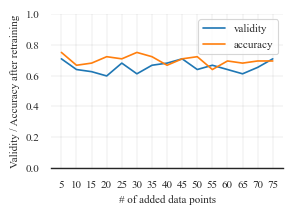

In [23]:
for names,_ in validity_dict_per_model.items():    
    acc=acc_dict_per_model[names]
    xval=validity_dict_per_model[names].keys()
    plt.figure(figsize=(3,2))
    plt.plot(list(xval)[1:],list(validity_dict_per_model[names].values())[1:],label='validity')
    plt.plot(list(xval)[1:],list(acc.values())[1:],label='accuracy')
    plt.xlabel('# of added data points', fontname='Times New Roman',fontsize=8)#fontweight='bold')fontname='Times New Roman',
    plt.ylabel('Validity / Accuracy after retraining',fontname='Times New Roman',fontsize=8)#, fontweight='bold')
    plt.xticks(rotation=0, fontname='Times New Roman',fontsize=8)#, fontweight='bold')
    plt.yticks(fontname='Times New Roman',fontsize=8)
    plt.ylim((0,1))
    
    sns.set_style('white')
    sns.set_context("paper", font_scale = 1)
    plt.grid(True, linestyle='-', linewidth=0.1, color='gray')

    font = fm.FontProperties(family='Times New Roman', size=8)
    plt.legend(prop=font, loc='upper right')

    sns.despine(right=True, left=True, top=True)
    plt.show()

In [16]:
# for names,_ in lof_dict_per_model.items():    
#     # acc=acc_dict_per_model[names]
#     xval=lof_dict_per_model[names].keys()
#     plt.plot(xval,lof_dict_per_model[names].values())
#     # plt.plot(xval,acc.values(),label='accuracy',c='red')
#     plt.xlabel('# of added data points', fontname='Times New Roman',fontsize=8)#fontweight='bold')fontname='Times New Roman',
#     plt.ylabel('Avg. LOF after retraining',fontname='Times New Roman',fontsize=8)#, fontweight='bold')
#     plt.xticks(rotation=0, fontname='Times New Roman',fontsize=8)#, fontweight='bold')
#     plt.yticks(fontname='Times New Roman',fontsize=8)
#     plt.ylim((0,1))
    
#     sns.set_style('white')
#     sns.set_context("paper", font_scale = 1)
#     plt.grid(True, linestyle='-', linewidth=0.1, color='gray')

#     font = fm.FontProperties(family='Times New Roman', size=8)
#     plt.legend(prop=font, loc='upper left')

#     sns.despine(right=True, left=True, top=True)
#     plt.show()

In [17]:
# for names,_ in dist_dict_per_model.items():    
#     # acc=acc_dict_per_model[names]
#     xval=dist_dict_per_model[names].keys()
#     plt.plot(xval,dist_dict_per_model[names].values())
#     # plt.plot(xval,acc.values(),label='accuracy',c='red')
#     plt.legend()
#     plt.xlabel('# of added data points')
#     plt.ylabel('Avg. L2 distance after retraining')
#     print(names)
#     plt.title(names+' and FOCUS')
#     plt.show()

In [18]:
print(sr_dict_per_model)

{'RandomForest': 1.0}


In [19]:
print(validity_dict_per_model)

{'RandomForest': {'0': 1.0, '5': 0.7083333333333334, '10': 0.6388888888888888, '15': 0.625, '20': 0.5972222222222222, '25': 0.6805555555555556, '30': 0.6111111111111112, '35': 0.6666666666666666, '40': 0.6805555555555556, '45': 0.7083333333333334, '50': 0.6388888888888888, '55': 0.6666666666666666, '60': 0.6388888888888888, '65': 0.6111111111111112, '70': 0.6527777777777778, '75': 0.7083333333333334}}


In [20]:
print(lof_dict_per_model)

{'RandomForest': {'0': -1.0871661871494165, '5': -1.0909251982598889, '10': -1.0848828590473687, '15': -1.0900989686951323, '20': -1.0831293782940732, '25': -1.0881643417472076, '30': -1.0858566220349186, '35': -1.085466181633902, '40': -1.0894437298357078, '45': -1.0878416728811044, '50': -1.086545448422899, '55': -1.0822580643868378, '60': -1.0829010326064035, '65': -1.0811152410598444, '70': -1.0858305057383637, '75': -1.0856308613737664}}


In [21]:
print(dist_dict_per_model)

{'RandomForest': {'0': 0.650557228400817, '5': 0.650557228400817, '10': 0.650557228400817, '15': 0.650557228400817, '20': 0.650557228400817, '25': 0.650557228400817, '30': 0.650557228400817, '35': 0.650557228400817, '40': 0.650557228400817, '45': 0.650557228400817, '50': 0.650557228400817, '55': 0.650557228400817, '60': 0.650557228400817, '65': 0.650557228400817, '70': 0.650557228400817, '75': 0.650557228400817}}
